DSML L 83

**TF KERAS SEQUENTIAL API**

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout
from tensorflow.keras.utils import to_categorical , plot_model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

In [2]:
print(tf.__version__)

2.19.0


In [3]:
#load mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


3


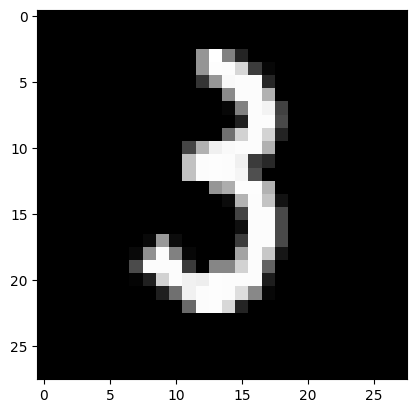

In [5]:
from matplotlib.image import interpolations_names
idx=1234
plt.imshow(x_train[idx], cmap='gray',interpolation ='none')
print(y_train[idx])


In [6]:
num_labels = len(np.unique(y_train))
print(num_labels)

10


In [7]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
#

In [8]:
image_size = x_train.shape[1]
input_size = image_size * image_size

#2d to 1d +normalize
x_train = np.reshape(x_train, [-1, input_size])
x_train = x_train.astype('float32') / 255
x_test = np.reshape(x_test, [-1, input_size])
x_test = x_test.astype('float32') / 255

In [9]:
batch_size = 128
hidden_units = 256

In [11]:
#swequential API

#3-layer MLP WITH ReLu
model = Sequential()
model.add(Dense(hidden_units, input_dim=input_size))
model.add(Activation('relu'))
model.add(Dense(hidden_units))
model.add(Activation('relu'))
model.add(Dense(num_labels))
#this is output for one-hot vector
model.add(Activation('softmax'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269,322 (1.03 MB)

 Trainable params: 269,322 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [15]:
model.fit(x_train,y_train,epochs=20,batch_size=batch_size)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9898 - loss: 0.0312
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9929 - loss: 0.0214
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9942 - loss: 0.0178
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9946 - loss: 0.0156
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9960 - loss: 0.0123
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9947 - loss: 0.0146
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9967 - loss: 0.0094
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9966 - loss: 0.0102
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9975 - loss: 0.0074
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9972 - loss: 0.0081
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9961 - loss: 0.0111
Epoch 12/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s

In [16]:
#text datset performnace
loss, acc = model.evaluate(x_test,
                           y_test,
                           batch_size=batch_size,
                           verbose =0)
print("\nTest accuracy: %.1f%%" % (100.0 * acc))
print(loss)



Test accuracy: 98.2%
0.09452784061431885


**TF2 KERAS FUNCTIONAL API**

In [17]:
print(x_train.shape)

(60000, 784)


In [20]:
inputs= keras.Input(shape=(784,))
inputs.shape

(None, 784)

In [21]:
#functional api

In [22]:
x1=layers.Dense(hidden_units, activation='relu')(inputs)
x2=layers.Dense(hidden_units, activation = 'relu')(x1)
outputs = layers.Dense(num_labels,activation='softmax')(x2)

model = keras.Model(inputs=inputs, outputs=outputs,name='simple_model')
model.summary()

In [ ]:
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [ ]:
model.fit(x_train,y_train,epochs=20,batch_size=batch_size)

DROPOUT:REGULARIZATION THROUGH RANDOMIZATION
